In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# DATASET SUMMARY
# ============================================================

def summarise_dataset(data, name, target_column=None):
    print(f"\n{'=' * 60}")
    print(f"{name.upper()} DATASET SUMMARY")
    print(f"{'=' * 60}")

    feature_count = data.shape[1]
    if target_column and target_column in data.columns:
        feature_count -= 1

    print(f"Number of records: {len(data)}")
    print(f"Number of features: {feature_count}")

    print("\nColumn names:")
    print(list(data.columns))

    print("\nMissing values:")
    missing_values = data.isnull().sum()
    missing_values = missing_values[missing_values > 0]

    if len(missing_values) == 0:
        print("No missing values.")
    else:
        print(missing_values)

    print("\nBasic statistics:")
    print(data.describe().round(2))

    if target_column and target_column in data.columns:
        print("\nTarget distribution:")
        print(data[target_column].value_counts())

        print("\nTarget percentage:")
        percentages = (
            data[target_column]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
        print(percentages)

    numeric_features = data.select_dtypes(include=["number"])

    constant_columns = [
        column
        for column in numeric_features.columns
        if numeric_features[column].nunique(dropna=True) <= 1
    ]

    if constant_columns:
        print("\nConstant features:")
        print(constant_columns)


# ============================================================
# DATA PREPARATION
# ============================================================

def prepare_features(data, target_column):

    labels = data[target_column].copy()

    features = data.drop(columns=[target_column])
    features = features.select_dtypes(include=["number"]).copy()

    # Remove features with no variation
    constant_columns = [
        column
        for column in features.columns
        if features[column].nunique(dropna=True) <= 1
    ]

    if constant_columns:
        print("\nRemoving constant features:")
        print(constant_columns)
        features = features.drop(columns=constant_columns)

    # Fill missing numerical values with median
    imputer = SimpleImputer(strategy="median")
    features_imputed = imputer.fit_transform(features)

    prepared_features = pd.DataFrame(
        features_imputed,
        columns=features.columns,
        index=features.index
    )

    return prepared_features, labels


# ============================================================
# RANDOM FOREST
# ============================================================

def run_random_forest(data, target_column, dataset_name):
    print(f"\n{'-' * 60}")
    print(f"Random Forest on {dataset_name} dataset")
    print(f"{'-' * 60}")

    if target_column not in data.columns:
        print("Random Forest skipped: target column not found.")
        return None

    features, labels = prepare_features(data, target_column)

    # Stratified split keeps the class proportions similar
    X_train, X_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.20,
        random_state=42,
        stratify=labels
    )

    rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    predictions = rf_model.predict(X_test)

    # --------------------------------------------------------
    # Feature importance
    # --------------------------------------------------------

    feature_importance = pd.Series(
        rf_model.feature_importances_,
        index=features.columns
    ).sort_values(ascending=False)

    print("\nMost important features:")
    print(feature_importance.head(10).round(4))

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    print("\nKey metrics:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    return {
        "model": "Random Forest",
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "feature_importance": feature_importance
    }


# ============================================================
# ISOLATION FOREST
# ============================================================

def run_isolation_forest(data, target_column, dataset_name):
    print(f"\n{'-' * 60}")
    print(f"Isolation Forest on {dataset_name} dataset")
    print(f"{'-' * 60}")

    if target_column not in data.columns:
        print("Isolation Forest skipped: target column not found.")
        return None

    actual_labels = data[target_column].copy()

    features = data.drop(columns=[target_column])
    features = features.select_dtypes(include=["number"]).copy()

    constant_columns = [
        column
        for column in features.columns
        if features[column].nunique(dropna=True) <= 1
    ]

    if constant_columns:
        print("\nRemoving constant features:")
        print(constant_columns)
        features = features.drop(columns=constant_columns)

    imputer = SimpleImputer(strategy="median")
    features_imputed = imputer.fit_transform(features)

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features_imputed)

    iso_model = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42,
        n_jobs=-1
    )

    raw_predictions = iso_model.fit_predict(scaled_features)

    predicted_anomalies = pd.Series(
        raw_predictions,
        index=data.index
    ).map({
        1: 0,
        -1: 1
    })

    anomaly_count = int(predicted_anomalies.sum())
    total_points = len(predicted_anomalies)
    anomaly_percentage = (
        anomaly_count / total_points
    ) * 100

    print("\nPredicted anomaly summary:")
    print(predicted_anomalies.value_counts())

    print(f"\nPredicted anomaly percentage: "
          f"{anomaly_percentage:.2f}%")

    # --------------------------------------------------------
    # Compare predictions with actual labels
    # --------------------------------------------------------

    precision = precision_score(
        actual_labels,
        predicted_anomalies,
        zero_division=0
    )

    recall = recall_score(
        actual_labels,
        predicted_anomalies,
        zero_division=0
    )

    f1 = f1_score(
        actual_labels,
        predicted_anomalies,
        zero_division=0
    )

    accuracy = accuracy_score(
        actual_labels,
        predicted_anomalies
    )

    print("\nComparison with actual labels:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            actual_labels,
            predicted_anomalies
        )
    )

    # --------------------------------------------------------
    # Analyse detected anomalies
    # --------------------------------------------------------

    original_numeric = data.drop(
        columns=[target_column]
    ).select_dtypes(include=["number"])

    detected_anomalies = original_numeric[
        predicted_anomalies == 1
    ]

    print("\nAverage values of detected anomalies:")
    print(
        detected_anomalies
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .round(2)
    )

    actual_anomalies = original_numeric[
        actual_labels == 1
    ]

    print("\nAverage values of actual anomalies:")
    print(
        actual_anomalies
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .round(2)
    )

    return {
        "model": "Isolation Forest",
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "anomalies": anomaly_count,
        "total": total_points,
        "anomaly_rate": anomaly_percentage
    }


# ============================================================
# LOAD DATASETS
# ============================================================

network_data = pd.read_csv(
    r"C:\Users\goutham\Downloads\embedded_system_network_security_dataset.csv"
)

cloud_data = pd.read_csv(
    r"C:\Users\goutham\Downloads\Cloud_Anomaly_Dataset.csv"
)


# ============================================================
# DATASET SUMMARIES
# ============================================================

summarise_dataset(
    network_data,
    "Network",
    "label"
)

summarise_dataset(
    cloud_data,
    "Cloud",
    "Anomaly status"
)


# ============================================================
# CLOUD FEATURE VARIATION
# ============================================================

print(f"\n{'=' * 60}")
print("CLOUD FEATURE VARIATION")
print(f"{'=' * 60}")

cloud_features = cloud_data.drop(
    columns=["Anomaly status"]
).select_dtypes(include=["number"])

cloud_variation = (
    cloud_features
    .std()
    .sort_values(ascending=False)
)

print(cloud_variation.round(2))


# ============================================================
# RUN ALL FOUR MODEL / DATASET COMBINATIONS
# ============================================================

results = []

print(f"\n{'=' * 60}")
print("NETWORK DATASET")
print(f"{'=' * 60}")

network_rf = run_random_forest(
    network_data,
    "label",
    "Network"
)

network_if = run_isolation_forest(
    network_data,
    "label",
    "Network"
)

results.extend(
    [network_rf, network_if]
)


print(f"\n{'=' * 60}")
print("CLOUD DATASET")
print(f"{'=' * 60}")

cloud_rf = run_random_forest(
    cloud_data,
    "Anomaly status",
    "Cloud"
)

cloud_if = run_isolation_forest(
    cloud_data,
    "Anomaly status",
    "Cloud"
)

results.extend(
    [cloud_rf, cloud_if]
)


# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

print(f"\n{'=' * 60}")
print("FINAL MODEL COMPARISON")
print(f"{'=' * 60}")

comparison_rows = []

for result in results:
    if result is None:
        continue

    comparison_rows.append({
        "Dataset": result["dataset"],
        "Model": result["model"],
        "Accuracy": round(result["accuracy"], 4),
        "Precision": round(result["precision"], 4),
        "Recall": round(result["recall"], 4),
        "F1-score": round(result["f1"], 4)
    })

comparison_table = pd.DataFrame(comparison_rows)

print(comparison_table.to_string(index=False))


# ============================================================
# BEST MODEL BY F1 SCORE
# ============================================================

if not comparison_table.empty:
    best_result = comparison_table.loc[
        comparison_table["F1-score"].idxmax()
    ]

    print(f"\nBest overall result based on F1-score:")
    print(
        f"{best_result['Model']} on "
        f"{best_result['Dataset']} dataset "
        f"(F1 = {best_result['F1-score']:.4f})"
    )


NETWORK DATASET SUMMARY
Number of records: 1000
Number of features: 17

Column names:
['packet_size', 'inter_arrival_time', 'src_port', 'dst_port', 'packet_count_5s', 'mean_packet_size', 'spectral_entropy', 'frequency_band_energy', 'label', 'protocol_type_TCP', 'protocol_type_UDP', 'src_ip_192.168.1.2', 'src_ip_192.168.1.3', 'dst_ip_192.168.1.5', 'dst_ip_192.168.1.6', 'tcp_flags_FIN', 'tcp_flags_SYN', 'tcp_flags_SYN-ACK']

Missing values:
No missing values.

Basic statistics:
       packet_size  inter_arrival_time  src_port  dst_port  packet_count_5s  \
count      1000.00             1000.00   1000.00   1000.00          1000.00   
mean          0.50                0.51  32024.62    199.77             0.51   
std           0.29                0.28  18520.89    180.08             0.30   
min           0.00                0.00   1038.00     53.00             0.00   
25%           0.26                0.28  16245.25     53.00             0.27   
50%           0.50                0.52  3188

In [2]:
# ============================================================
# CROSS VALIDATION + SMOTE (IMPROVED EVALUATION)
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import numpy as np

print("\n" + "="*60)
print("IMPROVED MODEL: SMOTE + STRATIFIED CROSS VALIDATION")
print("="*60)

# Prepare features (using your existing function)
X, y = prepare_features(network_data, "label")

# Apply SMOTE to balance dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Define model (same as your original)
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Stratified Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using F1 score (important for imbalance)
f1_scores = cross_val_score(
    rf_model,
    X_resampled,
    y_resampled,
    cv=cv,
    scoring="f1"
)

precision_scores = cross_val_score(
    rf_model,
    X_resampled,
    y_resampled,
    cv=cv,
    scoring="precision"
)

recall_scores = cross_val_score(
    rf_model,
    X_resampled,
    y_resampled,
    cv=cv,
    scoring="recall"
)

# Print results
print("\nCross-validation results (after SMOTE):")
print("F1 scores:", f1_scores)
print("Mean F1:", np.mean(f1_scores))

print("\nPrecision scores:", precision_scores)
print("Mean Precision:", np.mean(precision_scores))

print("\nRecall scores:", recall_scores)
print("Mean Recall:", np.mean(recall_scores))


IMPROVED MODEL: SMOTE + STRATIFIED CROSS VALIDATION

Removing constant features:
['mean_packet_size']

After SMOTE:
label
0.0    900
1.0    900
Name: count, dtype: int64

Cross-validation results (after SMOTE):
F1 scores: [0.91737892 0.9121813  0.90084986 0.93371758 0.92479109]
Mean F1: 0.9177837488907402

Precision scores: [0.94152047 0.93063584 0.91907514 0.97005988 0.9273743 ]
Mean Precision: 0.937733126482143

Recall scores: [0.89444444 0.89444444 0.88333333 0.9        0.92222222]
Mean Recall: 0.8988888888888888


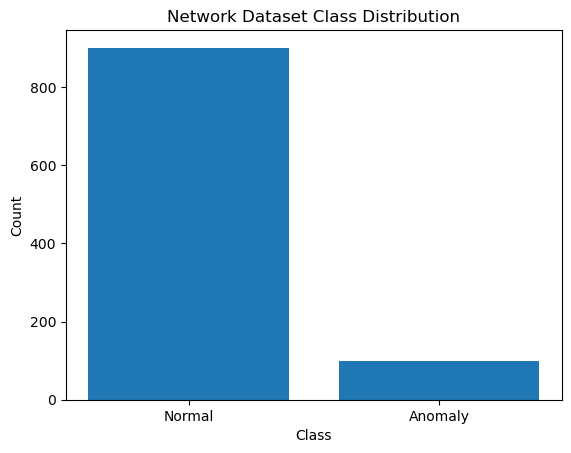

In [3]:
import matplotlib.pyplot as plt

# Data from your result
labels = ['Normal', 'Anomaly']
values = [900, 100]

plt.figure()
plt.bar(labels, values)
plt.title("Network Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

# SAVE IMAGE
plt.savefig("network_distribution.png")
plt.show()

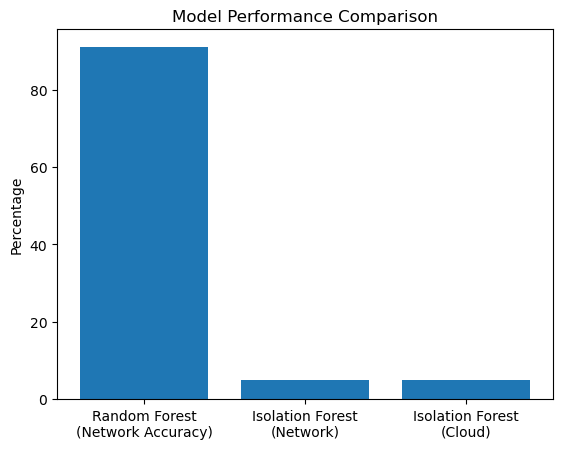

In [4]:
import matplotlib.pyplot as plt

models = [
    "Random Forest\n(Network Accuracy)",
    "Isolation Forest\n(Network)",
    "Isolation Forest\n(Cloud)"
]

values = [91, 5, 5]

plt.figure()
plt.bar(models, values)
plt.title("Model Performance Comparison")
plt.ylabel("Percentage")

plt.savefig("model_comparison.png")
plt.show()


Removing constant features:
['mean_packet_size']


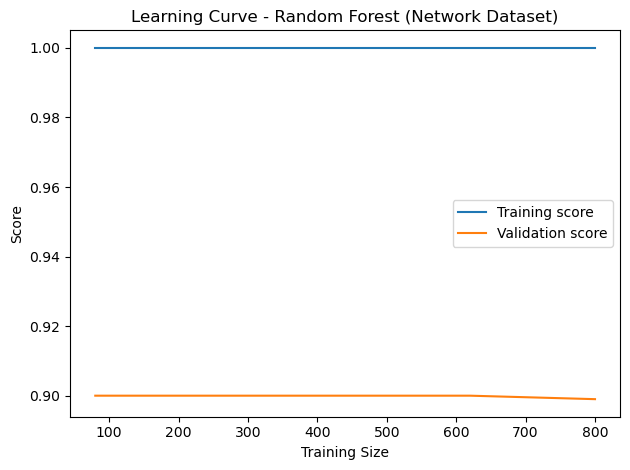

In [5]:
X, y = prepare_features(network_data, "label")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

train_sizes, train_scores, test_scores = learning_curve(
    rf_model,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, test_mean, label="Validation score")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.legend()
plt.title("Learning Curve - Random Forest (Network Dataset)")

plt.tight_layout()
plt.savefig("learning_curve.png", dpi=300)
plt.show()

In [6]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import precision_score, recall_score

rf_model.fit(X, y)
y_pred = rf_model.predict(X)


group = pd.qcut(X.iloc[:, 0], q=2, labels=["low", "high"])

# Evaluate fairness
mf = MetricFrame(
    metrics={
        "precision": precision_score,
        "recall": recall_score
    },
    y_true=y,
    y_pred=y_pred,
    sensitive_features=group
)

print("\nFairness analysis by group:")
print(mf.by_group)


Fairness analysis by group:
             precision  recall
packet_size                   
high               1.0     1.0
low                1.0     1.0


In [7]:
# Split first
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
rf_model.fit(X_train, y_train)

# Predict on unseen data
y_pred = rf_model.predict(X_test)

# Create groups on test set
group = pd.qcut(X_test.iloc[:, 0], q=2, labels=["low", "high"])

# Fairlearn
mf = MetricFrame(
    metrics={"precision": precision_score, "recall": recall_score},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=group
)

print(mf.by_group)

             precision  recall
packet_size                   
high               0.0     0.0
low                0.0     0.0


C:\Users\goutham\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\goutham\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\goutham\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


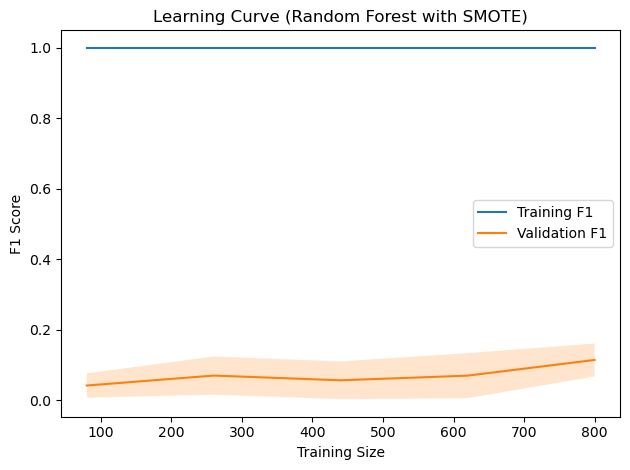

In [12]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import numpy as np
import matplotlib.pyplot as plt

pipeline = Pipeline([
    ('smote', SMOTE(k_neighbors=2,random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    pipeline,
    X, y,
    cv=cv,
    scoring='f1', 
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training F1")
plt.plot(train_sizes, val_mean, label="Validation F1")

# Optional (but gives extra marks)
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2)

plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve (Random Forest with SMOTE)")
plt.legend()

plt.tight_layout()
plt.savefig("learning_curve_new.png", dpi=300)
plt.show()

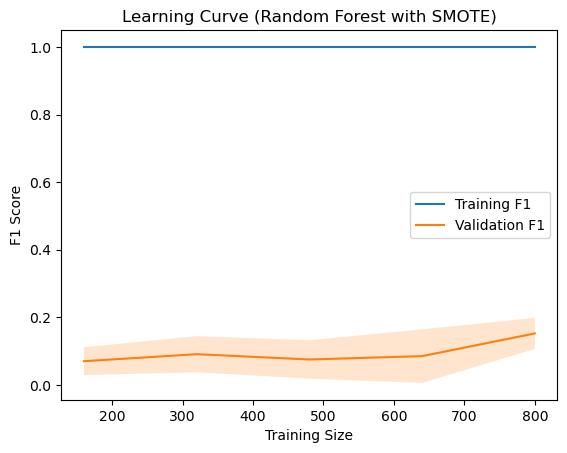

In [11]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    pipeline,
    X, y,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.plot(train_sizes, train_mean, label='Training F1')
plt.plot(train_sizes, val_mean, label='Validation F1')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.xlabel('Training Size')
plt.ylabel('F1 Score')
plt.title('Learning Curve (Random Forest with SMOTE)')
plt.legend()
plt.show()